# ConvNeXtV2

We evaluated nine ConvNeXtV2 experiments on the selected iNat2021 subset: two leveraging transfer learning (pretrained on ImageNet-22k) and seven trained from scratch.

Note on Naming Convention: Experiment names follow the pattern

`{initialization}_{with/without augmentation}[_{ablation_study}...]`

ID | ExperimentName | Init | Augmentation | DropPathRate | WarmupSteps |
|---|---|---|---|---|---|
| A | `pretrained_no_aug` | ImageNet-22k | None | 0.0 | 1,000 |
| B | `pretrained_aug` | ImageNet-22k | Basic | 0.0 | 1,000 |
| C | `scratch_no_aug` | random weights | None | 0.0 | 1,000 |
| D | `scratch_aug` | random weights | Basic | 0.0 | 1,000 |
| E | `scratch_aug_drop_path` | random weights | Basic | 0.1 | 1,000 |
| F | `scratch_aug_drop_path_coarse_dropout` | random weights | Basic + CoarseDropout | 0.1 | 1,000 |
| G | `scratch_aug_drop_path_coarse_dropout_cutmix_mixup` | random weights | Basic + CoarseDropout + CutMix/MixUp | 0.1 | 1,000 |
| H | `scratch_aug_drop_path_coarse_dropout_cutmix_mixup_warmup_10k` | random weights | Basic + CoarseDropout + CutMix/MixUp | 0.1 | 10,000 |
| I | `scratch_aug_drop_path_coarse_dropout_cutmix_mixup_warmup_30k` | random weights | Basic + CoarseDropout + CutMix/MixUp | 0.1 | 30,000 |


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Download data

## Download subsampling data from Sharepoint

In [ ]:
# !wget --content-disposition "https://unsw-my.sharepoint.com/:u:/g/personal/z5640942_ad_unsw_edu_au/IQD4tj3dbw7OQY0N68f0O28RAQr9BjpCM46knnnNpHz1nSc?download=1"
# !wget --content-disposition "https://unsw-my.sharepoint.com/:u:/g/personal/z5640942_ad_unsw_edu_au/IQDxA2T89sC9RbuE_Tq0ibp1AXt8GCrpYvlVR9w_MYcWNto?download=1"
# !cp "/content/train_select.zip" "/content/drive/MyDrive/Colab Notebooks/iNat2021_dataset/"
# !cp "/content/test_select.zip" "/content/drive/MyDrive/Colab Notebooks/iNat2021_dataset/"

## Extract zip file from Google Drive to Google Colab local storage

In [7]:
!mkdir -p /content/inat_mini/

!unzip -q "/content/drive/MyDrive/Colab Notebooks/iNat2021_dataset/train_select.zip" -d "/content/inat_mini/"
!unzip -q "/content/drive/MyDrive/Colab Notebooks/iNat2021_dataset/test_select.zip" -d "/content/inat_mini/"

!tar -xzf "/content/drive/MyDrive/iNat2021_Dataset/train_mini.json.tar.gz" -C "/content/inat_mini/"
!tar -xzf "/content/drive/MyDrive/iNat2021_Dataset/val.json.tar.gz" -C "/content/inat_mini/"

!find /content/inat_mini/train_select -type f | wc -l
!find /content/inat_mini/test_select -type f | wc -l

tar (child): /content/drive/MyDrive/iNat2021_Dataset/train_mini.json.tar.gz: Cannot open: No such file or directory
tar (child): Error is not recoverable: exiting now
tar: Child returned status 2
tar: Error is not recoverable: exiting now
tar (child): /content/drive/MyDrive/iNat2021_Dataset/val.json.tar.gz: Cannot open: No such file or directory
tar (child): Error is not recoverable: exiting now
tar: Child returned status 2
tar: Error is not recoverable: exiting now
50000
10000


# Setup

In [2]:
!pip install evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.1 MB/s eta 0:00:00


In [3]:
from pathlib import Path

import albumentations as A
import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from albumentations.pytorch import ToTensorV2
from datasets import DatasetDict, load_dataset
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch.distributions.beta import Beta
from transformers import (
    AutoConfig,
    AutoImageProcessor,
    AutoModelForImageClassification,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

RANDOM_SEED = 20269517
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DRIVE_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/iNat2021_dataset")
LOCAL_ROOT = Path("/content/inat_mini")

TRAIN_IMAGES_PATH = LOCAL_ROOT / "train_select"
TEST_IMAGES_PATH = LOCAL_ROOT / "test_select"

MODEL_SAVED_PATH = DRIVE_ROOT / "model"
MODEL_CHECKPOINT = DRIVE_ROOT / "model_checkpoint"

MODEL_SAVED_PATH.mkdir(parents=True, exist_ok=True)
MODEL_CHECKPOINT.mkdir(parents=True, exist_ok=True)

print(f"Drive root: {DRIVE_ROOT}")
print(f"Local data: {LOCAL_ROOT}")

Drive root: /content/drive/MyDrive/Colab Notebooks/iNat2021_dataset
Local data: /content/inat_mini


In [4]:
# Setup ablation studies
SAVE_TOTAL_LIMIT = 5

EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_THRESHOLD = 0.0

BATCH_SIZE = 128

WEIGHT_DECAY = 0.05
LABEL_SMOOTHING_FACTOR = 0.1


EXPERIMENTS = {
    "pretrained_no_aug": {
        "from_scratch": False, # init
        "augment": False, # basic augmentation
        "coarse_dropout": False, # coarse_dropout augmentation
        "use_cmmi": False, # cutmix/mixup augmentation
        "drop_path_rate": 0.0, # drop_path_rate
        "warmup_steps": 1000, # warmup_steps
        "learning_rate": 5e-5,
        "num_train_epochs": 150,
        "output_dir": MODEL_CHECKPOINT / "no_aug_pretrained_model_checkpoint",
        "save_dir": MODEL_SAVED_PATH / "no_aug_pretrained_model",
    },
    "pretrained_aug": {
        "from_scratch": False,
        "augment": True,
        "coarse_dropout": False,
        "use_cmmi": False,
        "drop_path_rate": 0.0,
        "warmup_steps": 1000,
        "learning_rate": 5e-5,
        "num_train_epochs": 150,
        "output_dir": MODEL_CHECKPOINT / "aug_pretrained_model_checkpoint",
        "save_dir": MODEL_SAVED_PATH / "aug_pretrained_model",
    },
    "scratch_no_aug": {
        "from_scratch": True,
        "augment": False,
        "coarse_dropout": False,
        "use_cmmi": False,
        "drop_path_rate": 0.0,
        "warmup_steps": 1000,
        "learning_rate": 1e-3,
        "num_train_epochs": 150,
        "output_dir": MODEL_CHECKPOINT / "scratch_model_checkpoint",
        "save_dir": MODEL_SAVED_PATH / "scratch_model",
    },
    "scratch_aug": {
        "from_scratch": True,
        "augment": True,
        "coarse_dropout": False,
        "use_cmmi": False,
        "drop_path_rate": 0.0,
        "warmup_steps": 1000,
        "learning_rate": 1e-3,
        "num_train_epochs": 150,
        "output_dir": MODEL_CHECKPOINT / "aug_scratch_model_checkpoint",
        "save_dir": MODEL_SAVED_PATH / "aug_scratch_model",
    },
    "scratch_aug_drop_path": {
        "from_scratch": True,
        "augment": True,
        "coarse_dropout": False,
        "use_cmmi": False,
        "drop_path_rate": 0.1,
        "warmup_steps": 1000,
        "learning_rate": 1e-3,
        "num_train_epochs": 150,
        "output_dir": MODEL_CHECKPOINT / "drop_rate_aug_scratch_model_checkpoint",
        "save_dir": MODEL_SAVED_PATH / "drop_rate_aug_scratch_model",
    },
    "scratch_aug_drop_path_coarse_dropout": {
        "from_scratch": True,
        "augment": True,
        "coarse_dropout": True,
        "use_cmmi": False,
        "drop_path_rate": 0.1,
        "warmup_steps": 1000,
        "learning_rate": 1e-3,
        "num_train_epochs": 150,
        "output_dir": MODEL_CHECKPOINT / "cd_drop_rate_aug_scratch_model_checkpoint",
        "save_dir": MODEL_SAVED_PATH / "cd_drop_rate_aug_scratch_model",
    },
    "scratch_aug_drop_path_coarse_dropout_cutmix_mixup": {
        "from_scratch": True,
        "augment": True,
        "coarse_dropout": True,
        "use_cmmi": True,
        "drop_path_rate": 0.1,
        "warmup_steps": 1000,
        "learning_rate": 1e-3,
        "num_train_epochs": 150,
        "output_dir": MODEL_CHECKPOINT / "cmmi_drop_rate_aug_scratch_model_checkpoint",
        "save_dir": MODEL_SAVED_PATH / "cmmi_drop_rate_aug_scratch_model",
    },
    "scratch_aug_drop_path_coarse_dropout_cutmix_mixup_warmup_10k": {
        "from_scratch": True,
        "augment": True,
        "coarse_dropout": True,
        "use_cmmi": True,
        "drop_path_rate": 0.1,
        "warmup_steps": 10000,
        "learning_rate": 1e-3,
        "num_train_epochs": 150,
        "output_dir": MODEL_CHECKPOINT
        / "w_cmmi_drop_rate_aug_scratch_model_checkpoint",
        "save_dir": MODEL_SAVED_PATH / "w_cmmi_drop_rate_aug_scratch_model",
    },
    "scratch_aug_drop_path_coarse_dropout_cutmix_mixup_warmup_30k": {
        "from_scratch": True,
        "augment": True,
        "coarse_dropout": True,
        "use_cmmi": True,
        "drop_path_rate": 0.1,
        "warmup_steps": 30000,
        "learning_rate": 1e-3,
        "num_train_epochs": 150,
        "output_dir": MODEL_CHECKPOINT
        / "w3_cmmi_drop_rate_aug_scratch_model_checkpoint",
        "save_dir": MODEL_SAVED_PATH / "w3_cmmi_drop_rate_aug_scratch_model",
    },
}

for config in EXPERIMENTS.values():
    Path(config["output_dir"]).mkdir(parents=True, exist_ok=True)
    Path(config["save_dir"]).mkdir(parents=True, exist_ok=True)

In [5]:
MODEL_NAME = "facebook/convnextv2-tiny-22k-224"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Model name: {MODEL_NAME}")
print(f"Available device: {DEVICE}")

Model name: facebook/convnextv2-tiny-22k-224
Available device: cuda


# Data Loading

In [8]:
# Download raw train dataset
raw_train = load_dataset("imagefolder", data_dir=TRAIN_IMAGES_PATH)
print(raw_train)

Resolving data files:   0%|          | 0/50000 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 50000
    })
})


Label: 00008_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Araneus_bicentenarius (id=2)


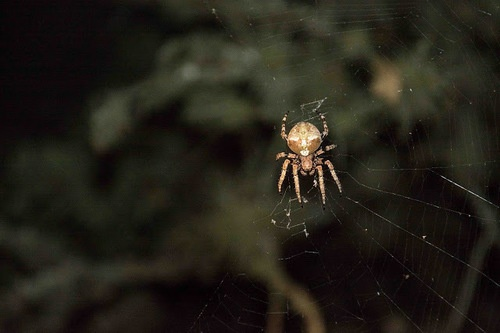

In [9]:
def display_image(dataset: DatasetDict, split: str, index: int):
    image = dataset[split][index]["image"]

    label_id = dataset[split][index]["label"]
    label_name = dataset[split].features["label"].int2str(label_id)

    print(f"Label: {label_name} (id={label_id})")
    display(image)


display_image(raw_train, "train", 100)

In [10]:
# Split raw train dataset into actual train and validation dataset
split = raw_train["train"].train_test_split(
    test_size=0.2,
    seed=RANDOM_SEED,
    stratify_by_column="label",
)
train_dataset = DatasetDict({
    "train": split["train"],
    "validation": split["test"],
})
print(train_dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 40000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})


In [11]:
# Download test dataset
test_dataset = load_dataset("imagefolder", data_dir=TEST_IMAGES_PATH)
test_dataset = DatasetDict({"test": test_dataset["train"]})
print(test_dataset)

Resolving data files:   0%|          | 0/10000 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})


In [12]:
# Create label name mapping
labels = train_dataset["train"].features["label"].names
num_classes = len(labels)

label2id = {label: str(i) for i, label in enumerate(labels)}
id2label = {str(i): label for i, label in enumerate(labels)}

print(f"There are {num_classes} classes.")

There are 1000 classes.


# Data Augmentation

In [13]:
# Retrieve some preprocessor parameters for data augmentation
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

HEIGHT = processor.size["shortest_edge"]
WIDTH = processor.size["shortest_edge"]
IMAGE_MEAN = processor.image_mean # ImageNet parameters
IMAGE_STD = processor.image_std # ImageNet parameters

print(f"height: {HEIGHT}")
print(f"width: {WIDTH}")

print(f"image_mean: {IMAGE_MEAN}")
print(f"image_std: {IMAGE_STD}")

preprocessor_config.json:   0%|          | 0.00/352 [00:00<?, ?B/s]

height: 224
width: 224
image_mean: (0.485, 0.456, 0.406)
image_std: (0.229, 0.224, 0.225)


In [14]:
# Initialize image-level transformation
def build_transforms(augment: bool, coarse_dropout: bool = False):
    # For validation/test dataset
    validation_transform = A.Compose(
        [
            A.SmallestMaxSize(max_size=256),
            A.CenterCrop(height=HEIGHT, width=WIDTH),
            A.Normalize(mean=IMAGE_MEAN, std=IMAGE_STD),
            ToTensorV2(),
        ],
        seed=RANDOM_SEED,
    )
    if not augment:
        return validation_transform, validation_transform

    # For training dataset
    train_ops = [
        A.RandomResizedCrop(size=(HEIGHT, WIDTH), scale=(0.7, 1.0), p=1.0),
        A.HorizontalFlip(p=0.5),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.5),
    ]
    if coarse_dropout:
        train_ops.append(
            A.CoarseDropout(
                num_holes_range=(3, 8),
                hole_height_range=(0.05, 0.15),
                hole_width_range=(0.05, 0.15),
                p=0.5,
            )
        )
    train_ops.extend(
        [
            A.Normalize(mean=IMAGE_MEAN, std=IMAGE_STD),
            ToTensorV2(),
        ]
    )
    train_transform = A.Compose(train_ops, seed=RANDOM_SEED)
    return train_transform, validation_transform

In [15]:
# Initialize batch-level transformation
def apply_mixup(pixel_values: torch.Tensor, targets: torch.Tensor, alpha: float = 0.8):
    """Blend pixels together"""
    lambd = Beta(alpha, alpha).sample().item()
    random_index = torch.randperm(pixel_values.size(0), device=pixel_values.device)

    mixed_pixels = (lambd * pixel_values) + ((1 - lambd) * pixel_values[random_index])
    mixed_targets = (lambd * targets) + ((1 - lambd) * targets[random_index])

    return mixed_pixels, mixed_targets


def apply_cutmix(pixel_values: torch.Tensor, targets: torch.Tensor, alpha: float = 1.0):
    """Cut one image to put it in another image"""
    lambd = Beta(alpha, alpha).sample().item()
    random_index = torch.randperm(pixel_values.size(0), device=pixel_values.device)

    _, _, height, width = pixel_values.shape

    cut_ratio = torch.sqrt(torch.tensor(1.0 - lambd)).item()
    cut_width = int(width * cut_ratio)
    cut_height = int(height * cut_ratio)

    center_x = torch.randint(0, width, (1,)).item()
    center_y = torch.randint(0, height, (1,)).item()

    x1 = max(center_x - cut_width // 2, 0)
    y1 = max(center_y - cut_height // 2, 0)
    x2 = min(center_x + cut_width // 2, width)
    y2 = min(center_y + cut_height // 2, height)

    pixel_values[:, :, y1:y2, x1:x2] = pixel_values[random_index, :, y1:y2, x1:x2]

    target_ratio = 1.0 - ((x2 - x1) * (y2 - y1) / (width * height))
    mixed_targets = (target_ratio * targets) + ((1 - target_ratio) * targets[random_index])

    return pixel_values, mixed_targets


# Custom Trainer has to be defined for utilizing CutMix/MixUp technique
class CMMITrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        if not model.training:
            return super().compute_loss(model, inputs, return_outputs, **kwargs)

        pixel_values = inputs.get("pixel_values").clone()
        labels = inputs.get("labels")

        targets = F.one_hot(labels, num_classes=model.config.num_labels).float()

        # Apply augmentations (50% MixUp, 50% CutMix)
        if torch.rand(1).item() < 0.5:
            pixel_values, targets = apply_mixup(pixel_values, targets)
        else:
            pixel_values, targets = apply_cutmix(pixel_values, targets)

        outputs = model(pixel_values=pixel_values)

        loss_function = torch.nn.CrossEntropyLoss(
            label_smoothing=self.args.label_smoothing_factor
        )
        loss = loss_function(outputs.logits, targets)

        return (loss, outputs) if return_outputs else loss

In [16]:
# Create helper functions for image augmentation process
def transform_fn(examples, transform):
    processed_images = [
        transform(image=np.array(img.convert("RGB")))["image"]
        for img in examples["image"]
    ]
    return {"pixel_values": processed_images, "label": examples["label"]}


def apply_transforms(
    train_dataset,
    validation_dataset,
    test_dataset,
    augment: bool,
    coarse_dropout: bool = False,
):
    # initiate transformation method
    train_transform, validation_transform = build_transforms(
        augment, coarse_dropout=coarse_dropout
    )

    # apply transformation and create dataset
    train_dataset = train_dataset.with_transform(
        lambda x: transform_fn(x, train_transform)
    )
    validation_dataset = validation_dataset.with_transform(
        lambda x: transform_fn(x, validation_transform)
    )
    test_dataset = test_dataset.with_transform(
        lambda x: transform_fn(x, validation_transform)
    )
    return train_dataset, validation_dataset, test_dataset

# Model Training Initialization

In [17]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "f1": f1}

In [18]:
def generate_training_arguments(config: dict) -> TrainingArguments:
    return TrainingArguments(
        output_dir=config["output_dir"],
        save_strategy="epoch",
        save_total_limit=SAVE_TOTAL_LIMIT,
        load_best_model_at_end=True,

        num_train_epochs=config["num_train_epochs"],
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        dataloader_num_workers=2,
        fp16=torch.cuda.is_available(),

        learning_rate=config["learning_rate"],
        lr_scheduler_type="cosine",
        warmup_steps=config["warmup_steps"],
        weight_decay=WEIGHT_DECAY,
        label_smoothing_factor=LABEL_SMOOTHING_FACTOR,

        eval_strategy="epoch",
        metric_for_best_model="accuracy",
        greater_is_better=True,

        logging_strategy="steps",
        logging_steps=10,
        report_to="none",

        remove_unused_columns=False,
        label_names=["labels"],
    )

In [19]:
# Create helper functions for data loader in Trainer
def collate_fn(examples):
    pixel_values = torch.stack(
        [
            ex["pixel_values"].clone().detach()
            if isinstance(ex["pixel_values"], torch.Tensor)
            else torch.as_tensor(ex["pixel_values"])
            for ex in examples
        ]
    )
    labels_tensor = torch.tensor([ex["label"] for ex in examples], dtype=torch.long)
    return {"pixel_values": pixel_values, "labels": labels_tensor}

In [20]:
def download_model(from_scratch: bool, drop_path_rate: float = 0.0):
    if from_scratch:
        config = AutoConfig.from_pretrained(
            MODEL_NAME,
            num_labels=num_classes,
            id2label=id2label,
            label2id=label2id,
            drop_path_rate=drop_path_rate,
        )
        model = AutoModelForImageClassification.from_config(config)
    else:
        model = AutoModelForImageClassification.from_pretrained(
            MODEL_NAME,
            num_labels=num_classes,
            id2label=id2label,
            label2id=label2id,
            ignore_mismatched_sizes=True,
        )
    return model.to(DEVICE)


def plot_loss_curves(trainer, title):
    history = trainer.state.log_history

    train_loss = [log["loss"] for log in history if "loss" in log]
    train_epochs = [log["epoch"] for log in history if "loss" in log]

    val_loss = [log["eval_loss"] for log in history if "eval_loss" in log]
    val_epochs = [log["epoch"] for log in history if "eval_loss" in log]

    plt.figure(figsize=(8, 4))

    plt.plot(train_epochs, train_loss, label="Training Loss", linestyle="-", marker="o")
    plt.plot(val_epochs, val_loss, label="Validation Loss", linestyle="--", marker="s")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(MODEL_SAVED_PATH / f"loss_curve_{title}.png")
    plt.show()


def latest_checkpoint(dir_path: Path):
    dir_path = Path(dir_path)
    if not dir_path.exists():
        return None
    checkpoints = sorted(
        dir_path.glob("checkpoint-*"),
        key=lambda p: int(p.name.split("-")[-1]),
    )
    return str(checkpoints[-1]) if checkpoints else None

# Model Training

In [21]:
def run_experiment(name: str, config: dict, resume: bool = True):
    print(f"Experiment: {name}")

    transformed_train, transformed_validation, _ = apply_transforms(
        train_dataset["train"],
        train_dataset["validation"],
        test_dataset["test"],
        augment=config["augment"],
        coarse_dropout=config.get("coarse_dropout", False),
    )

    model = download_model(
        from_scratch=config["from_scratch"],
        drop_path_rate=config.get("drop_path_rate", 0.0),
    )
    training_arguments = generate_training_arguments(config)

    trainer_class = CMMITrainer if config.get("use_cmmi", False) else Trainer
    trainer = trainer_class(
        model=model,
        args=training_arguments,
        train_dataset=transformed_train,
        eval_dataset=transformed_validation,
        data_collator=collate_fn,
        compute_metrics=compute_metrics,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=EARLY_STOPPING_PATIENCE,
                early_stopping_threshold=EARLY_STOPPING_THRESHOLD,
            )
        ],
    )

    checkpoint = latest_checkpoint(config["output_dir"]) if resume else None
    if checkpoint:
        print(f"Resuming from checkpoint: {checkpoint}")
        train_result = trainer.train(resume_from_checkpoint=checkpoint)
    else:
        train_result = trainer.train()

    save_dir = Path(config["save_dir"])
    save_dir.mkdir(parents=True, exist_ok=True)

    processor.save_pretrained(save_dir)
    trainer.save_model(save_dir)
    trainer.save_state()
    trainer.save_metrics("train", train_result.metrics)

    plot_loss_curves(trainer, title=f"{name} loss curves")

## A - pretrained_no_aug

Experiment: pretrained_no_aug


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Resuming from checkpoint: /content/drive/MyDrive/Colab Notebooks/iNat2021_dataset/model_checkpoint/no_aug_pretrained_model_checkpoint/checkpoint-500


[transformers] Warning: The following arguments do not match the ones in the `trainer_state.json` within the checkpoint directory: 
	per_device_train_batch_size: 128 (from args) != 64 (from trainer_state.json)


Epoch,Training Loss,Validation Loss,Accuracy,F1
2,4.480869,4.370878,0.318600,0.278717
3,3.017710,3.056414,0.578500,0.558886
4,2.090530,2.386865,0.703200,0.696962
5,1.627690,2.166862,0.739800,0.738079
6,1.386842,2.087725,0.755500,0.753871
7,1.218410,2.072893,0.762200,0.760834
8,1.143559,2.085520,0.763500,0.761985
9,1.109302,2.084433,0.766500,0.764739
10,1.097705,2.086823,0.772500,0.770771
11,1.080774,2.101152,0.775300,0.773528


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

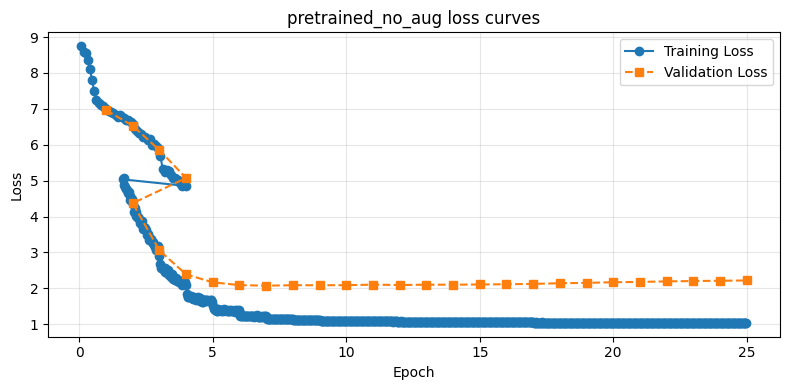

In [ ]:
experiment_name = "pretrained_no_aug"
run_experiment(experiment_name, EXPERIMENTS[experiment_name])

## B - pretrained_aug

Experiment: pretrained_aug


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  115MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

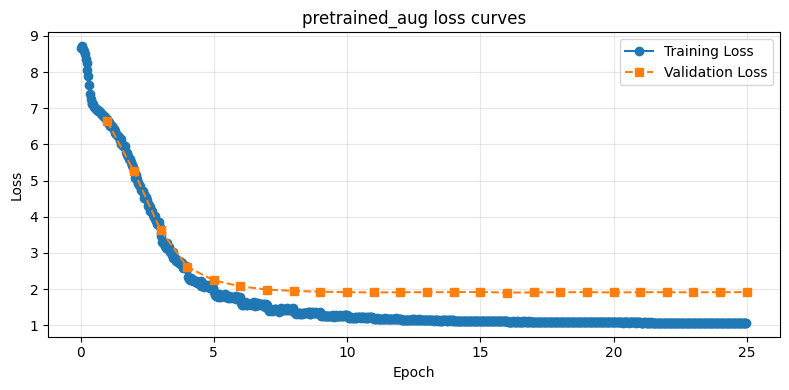

In [ ]:
experiment_name = "pretrained_aug"
run_experiment(experiment_name, EXPERIMENTS[experiment_name])

## C - scratch_no_aug

Experiment: scratch_no_aug
Starting fresh training (no checkpoint found).


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,6.693956,6.681290,0.005000,0.000457
2,6.378803,6.440136,0.012100,0.003557
3,6.119471,6.100259,0.024300,0.012829
4,5.796200,5.764118,0.052500,0.033580
5,5.381475,5.533355,0.071800,0.051893
6,5.223877,5.404247,0.088800,0.070211
7,4.911952,5.236334,0.113300,0.095391
8,4.474497,5.197380,0.118700,0.108740
9,4.174458,5.269543,0.132300,0.121026
10,3.651288,5.528769,0.126200,0.115097


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

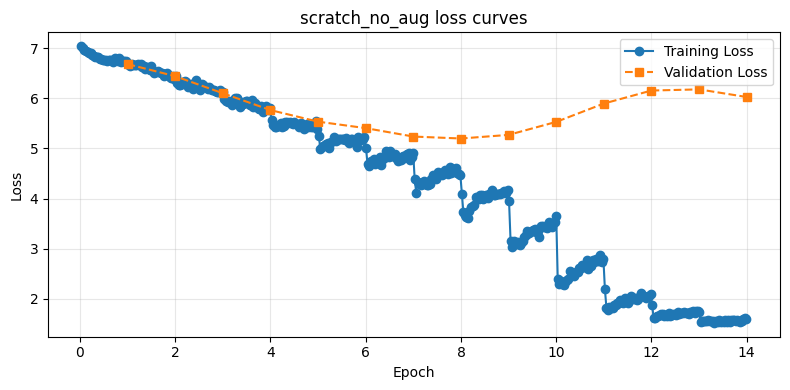

In [ ]:
experiment_name = "scratch_no_aug"
run_experiment(experiment_name, EXPERIMENTS[experiment_name])

## D - scratch_aug

Experiment: scratch_aug


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

Starting fresh training (no checkpoint found).


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,6.719142,6.712023,0.004000,0.000334
2,6.460593,6.506680,0.010600,0.003203
3,6.228790,6.176031,0.021200,0.009629
4,5.933588,5.878259,0.040900,0.023360
5,5.579494,5.639630,0.057500,0.036746
6,5.456735,5.454111,0.079600,0.057929
7,5.235603,5.281746,0.096900,0.077335
8,4.875627,5.217152,0.108600,0.091221
9,4.846059,5.109720,0.127900,0.110430
10,4.607372,5.046069,0.137000,0.119360


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

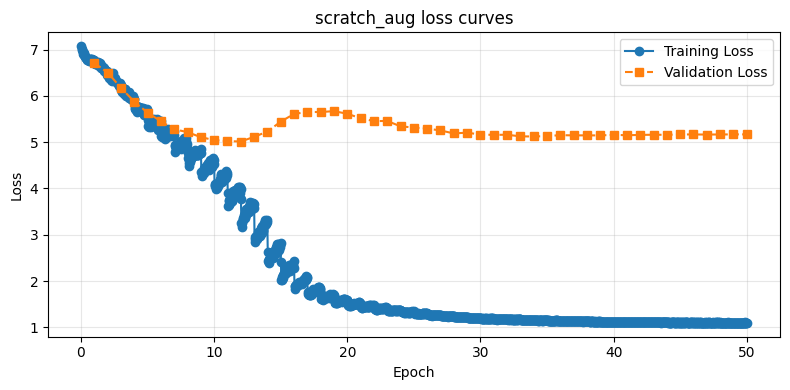

In [ ]:
experiment_name = "scratch_aug"
run_experiment(experiment_name, EXPERIMENTS[experiment_name])

## E - scratch_aug_drop_path

Experiment: drop_rate_scratch_aug


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

Starting fresh training (no checkpoint found).


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,6.734452,6.707033,0.004500,0.000593
2,6.485081,6.525081,0.008700,0.002849
3,6.265604,6.217412,0.019600,0.009541
4,6.025737,5.933672,0.035800,0.020980
5,5.636011,5.652001,0.057900,0.038634
6,5.547689,5.503007,0.071400,0.052972
7,5.343582,5.330235,0.093700,0.072802
8,4.982661,5.196125,0.112800,0.095240
9,4.922759,5.085550,0.127700,0.112665
10,4.785994,5.000947,0.142700,0.125861


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

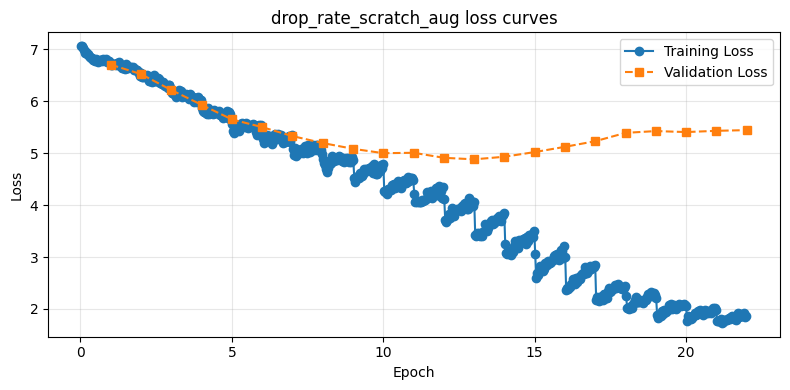

In [ ]:
experiment_name = "scratch_aug_drop_path"
run_experiment(experiment_name, EXPERIMENTS[experiment_name])

## F - scratch_aug_drop_path_coarse_dropout

Experiment: cd_drop_rate_scratch_aug
Starting fresh training (no checkpoint found).


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,6.738065,6.713811,0.004800,0.000407
2,6.536486,6.551416,0.007700,0.002394
3,6.295371,6.231441,0.019400,0.008901
4,6.096634,5.985455,0.031400,0.015976
5,5.752300,5.812632,0.043600,0.027443
6,5.632051,5.547698,0.069500,0.049396
7,5.408576,5.356701,0.091300,0.071765
8,5.090121,5.255127,0.104500,0.085780
9,5.063641,5.165687,0.113900,0.096520
10,4.886290,5.112803,0.119100,0.100675


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

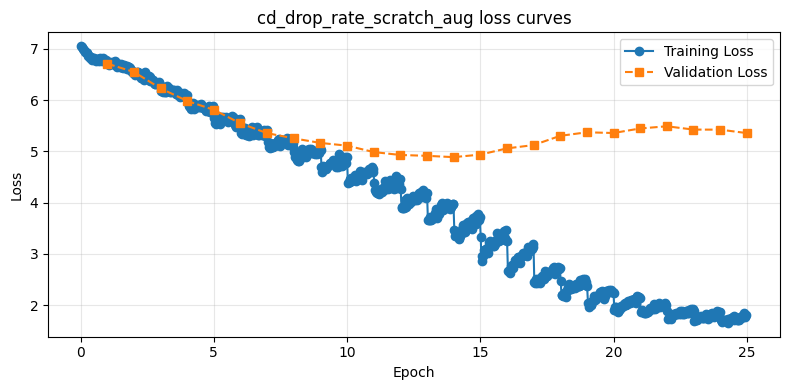

In [ ]:
experiment_name = "scratch_aug_drop_path_coarse_dropout"
run_experiment(experiment_name, EXPERIMENTS[experiment_name])

## G - scratch_aug_drop_path_coarse_dropout_cutmix_mixup


Experiment: cmmi_drop_rate_scratch_aug


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

use CMMI Trainer
Starting fresh training (no checkpoint found).


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,6.856042,6.783841,0.003800,0.000496
2,6.869987,6.725341,0.002700,0.000228
3,6.718217,6.528794,0.007900,0.001904
4,6.640194,6.336278,0.015400,0.005850
5,6.482063,6.148242,0.022000,0.008623
6,6.310210,5.969498,0.033600,0.017057
7,6.350447,5.834313,0.046000,0.027430
8,6.130811,5.675444,0.058700,0.038604
9,6.211917,5.564502,0.068700,0.046490
10,6.117969,5.494052,0.075900,0.051797


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

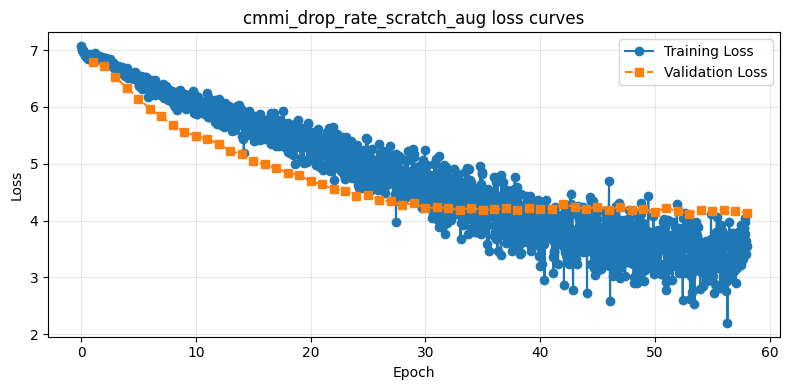

In [ ]:
experiment_name = "scratch_aug_drop_path_coarse_dropout_cutmix_mixup"
run_experiment(experiment_name, EXPERIMENTS[experiment_name])

## H - scratch_aug_drop_path_coarse_dropout_cutmix_mixup_warmup_10k

Experiment: w_cmmi_drop_rate_scratch_aug


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

use CMMI Trainer
Starting fresh training (no checkpoint found).


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,6.830190,6.755101,0.003800,0.000528
2,6.804515,6.666583,0.005500,0.000927
3,6.713251,6.576693,0.006100,0.001557
4,6.692660,6.484355,0.011500,0.003423
5,6.575444,6.312108,0.018000,0.006484
6,6.476150,6.211042,0.024800,0.011310
7,6.503592,6.153328,0.027100,0.012311
8,6.382769,6.069352,0.034200,0.018118
9,6.384423,5.930775,0.035900,0.020559
10,6.307257,5.811382,0.051300,0.029702


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

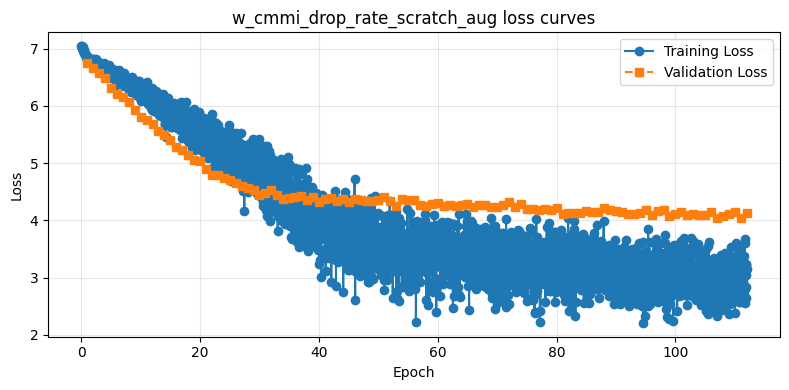

In [ ]:
experiment_name = "scratch_aug_drop_path_coarse_dropout_cutmix_mixup_warmup_10k"
run_experiment(experiment_name, EXPERIMENTS[experiment_name])

## I - scratch_aug_drop_path_coarse_dropout_cutmix_mixup_warmup_30k

Experiment: w3_cmmi_drop_rate_scratch_aug


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

use CMMI Trainer
Starting fresh training (no checkpoint found).


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,6.877907,6.837688,0.003400,0.000429
2,6.822437,6.707514,0.004100,0.000540
3,6.745119,6.650640,0.006100,0.000938
4,6.742358,6.578638,0.007300,0.001454
5,6.672598,6.508878,0.013000,0.003094
6,6.571650,6.411891,0.016500,0.005226
7,6.598766,6.323871,0.020600,0.007632
8,6.485754,6.241310,0.023700,0.010135
9,6.507040,6.190549,0.025400,0.010331
10,6.464597,6.120276,0.028900,0.013493


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

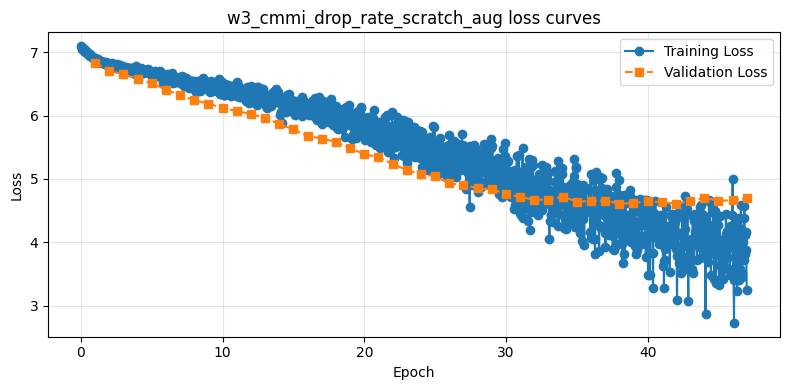

In [ ]:
experiment_name = "scratch_aug_drop_path_coarse_dropout_cutmix_mixup_warmup_30k"
run_experiment(experiment_name, EXPERIMENTS[experiment_name])

# Model Evaluation

In [22]:
saved_test_predictions = {}


def evaluate_predictions(logits, labels_arr, k=5):
    preds = np.argmax(logits, axis=1)
    # top-k: true label in top-k predicted classes
    topk_idx = np.argpartition(logits, -k, axis=1)[:, -k:]
    topk_acc = float(np.mean([y in row for y, row in zip(labels_arr, topk_idx)]))
    return {
        "top1_accuracy": float(accuracy_score(labels_arr, preds)),
        "top5_accuracy": topk_acc,
        "balanced_accuracy": float(balanced_accuracy_score(labels_arr, preds)),
        "macro_precision": float(
            precision_score(labels_arr, preds, average="macro", zero_division=0)
        ),
        "macro_recall": float(
            recall_score(labels_arr, preds, average="macro", zero_division=0)
        ),
        "macro_f1": float(
            f1_score(labels_arr, preds, average="macro", zero_division=0)
        ),
    }


def evaluate_experiment(experiment_name: str):
    config = EXPERIMENTS[experiment_name]
    saved_model_path = config["save_dir"]

    print(f"Experiment: {experiment_name}")
    print(f"Loading model from {saved_model_path}")
    model = AutoModelForImageClassification.from_pretrained(saved_model_path)
    model.to(DEVICE)
    model.eval()

    _, _, transformed_test = apply_transforms(
        train_dataset["train"],
        train_dataset["validation"],
        test_dataset["test"],
        augment=False,
        coarse_dropout=False,
    )

    eval_args = TrainingArguments(
        output_dir=config["output_dir"],
        per_device_eval_batch_size=BATCH_SIZE,
        remove_unused_columns=False,
        report_to="none",
    )
    eval_trainer = Trainer(
        model=model,
        args=eval_args,
        data_collator=collate_fn,
        compute_metrics=compute_metrics,
    )
    test_output = eval_trainer.predict(transformed_test)

    all_logits = test_output.predictions
    true_labels = test_output.label_ids
    pred_labels = np.argmax(all_logits, axis=1)

    metrics = evaluate_predictions(all_logits, true_labels)
    print("\nOverall Metrics:")
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")

    # Per-class metrics for error analysis
    report = classification_report(
        true_labels, pred_labels, output_dict=True, zero_division=0
    )
    f1_scores = {int(k): v["f1-score"] for k, v in report.items() if k.isdigit()}

    sorted_f1 = sorted(f1_scores.items(), key=lambda x: x[1])
    low_f1_classes = [c[0] for c in sorted_f1[:3]]
    high_f1_classes = [c[0] for c in sorted_f1[-3:]]

    print("\nClasses with lowest F1 scores:")
    for class_id in low_f1_classes:
        print(
            f"Class {class_id} ({id2label[str(class_id)]}): {f1_scores[class_id]:.4f}"
        )

    print("\nClasses with highest F1 scores:")
    for class_id in high_f1_classes:
        print(
            f"Class {class_id} ({id2label[str(class_id)]}): {f1_scores[class_id]:.4f}"
        )

    saved_test_predictions[experiment_name] = pd.DataFrame({
        "true_species_id": true_labels,
        "prediction_species_id": pred_labels,
    })

    return metrics

## A - pretrained_no_aug


In [23]:
evaluate_experiment("pretrained_no_aug")

Experiment: pretrained_no_aug
Loading model from /content/drive/MyDrive/Colab Notebooks/iNat2021_dataset/model/no_aug_pretrained_model


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


Overall Metrics:
top1_accuracy: 0.7877
top5_accuracy: 0.9204
balanced_accuracy: 0.7877
macro_precision: 0.8030
macro_recall: 0.7877
macro_f1: 0.7869

Classes with lowest F1 scores:
Class 321 (03402_Animalia_Chordata_Aves_Charadriiformes_Laridae_Chroicocephalus_ridibundus): 0.1905
Class 307 (03292_Animalia_Chordata_Aves_Caprimulgiformes_Caprimulgidae_Chordeiles_minor): 0.2308
Class 68 (00713_Animalia_Arthropoda_Insecta_Hymenoptera_Apidae_Xylocopa_tabaniformis): 0.2353

Classes with highest F1 scores:
Class 810 (07979_Plantae_Tracheophyta_Magnoliopsida_Fabales_Fabaceae_Lathyrus_hirsutus): 1.0000
Class 842 (08313_Plantae_Tracheophyta_Magnoliopsida_Gentianales_Gentianaceae_Sabatia_campestris): 1.0000
Class 878 (08803_Plantae_Tracheophyta_Magnoliopsida_Malpighiales_Euphorbiaceae_Euphorbia_oblongata): 1.0000


{'top1_accuracy': 0.7877,
 'top5_accuracy': 0.9204,
 'balanced_accuracy': 0.7877000000000001,
 'macro_precision': 0.802976679422229,
 'macro_recall': 0.7877000000000001,
 'macro_f1': 0.7868756277654163}

## B - pretrained_aug


In [24]:
evaluate_experiment("pretrained_aug")

Experiment: pretrained_aug
Loading model from /content/drive/MyDrive/Colab Notebooks/iNat2021_dataset/model/aug_pretrained_model


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


Overall Metrics:
top1_accuracy: 0.8100
top5_accuracy: 0.9320
balanced_accuracy: 0.8100
macro_precision: 0.8244
macro_recall: 0.8100
macro_f1: 0.8097

Classes with lowest F1 scores:
Class 307 (03292_Animalia_Chordata_Aves_Caprimulgiformes_Caprimulgidae_Chordeiles_minor): 0.1053
Class 321 (03402_Animalia_Chordata_Aves_Charadriiformes_Laridae_Chroicocephalus_ridibundus): 0.2857
Class 67 (00711_Animalia_Arthropoda_Insecta_Hymenoptera_Apidae_Xylocopa_micans): 0.3529

Classes with highest F1 scores:
Class 907 (09111_Plantae_Tracheophyta_Magnoliopsida_Piperales_Aristolochiaceae_Asarum_caudatum): 1.0000
Class 965 (09656_Plantae_Tracheophyta_Magnoliopsida_Saxifragales_Saxifragaceae_Lithophragma_affine): 1.0000
Class 990 (09920_Plantae_Tracheophyta_Polypodiopsida_Polypodiales_Blechnaceae_Telmatoblechnum_serrulatum): 1.0000


{'top1_accuracy': 0.81,
 'top5_accuracy': 0.932,
 'balanced_accuracy': 0.81,
 'macro_precision': 0.824406467225585,
 'macro_recall': 0.81,
 'macro_f1': 0.8097094888636388}

## C - scratch_no_aug


In [25]:
evaluate_experiment("scratch_no_aug")

Experiment: scratch_no_aug
Loading model from /content/drive/MyDrive/Colab Notebooks/iNat2021_dataset/model/scratch_model


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


Overall Metrics:
top1_accuracy: 0.1287
top5_accuracy: 0.2984
balanced_accuracy: 0.1287
macro_precision: 0.1479
macro_recall: 0.1287
macro_f1: 0.1149

Classes with lowest F1 scores:
Class 3 (00011_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Araneus_quadratus): 0.0000
Class 5 (00037_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_arabesca): 0.0000
Class 6 (00047_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Trichonephila_fenestrata): 0.0000

Classes with highest F1 scores:
Class 604 (05928_Plantae_Tracheophyta_Liliopsida_Asparagales_Asparagaceae_Scilla_siberica): 0.7273
Class 620 (06138_Plantae_Tracheophyta_Liliopsida_Liliales_Liliaceae_Calochortus_leichtlinii): 0.7619
Class 532 (05298_Animalia_Mollusca_Gastropoda_Nudibranchia_Chromodorididae_Chromodoris_annae): 0.7778


{'top1_accuracy': 0.1287,
 'top5_accuracy': 0.2984,
 'balanced_accuracy': 0.1287,
 'macro_precision': 0.1478728410786624,
 'macro_recall': 0.1287,
 'macro_f1': 0.1148794660968229}

## D - scratch_aug


In [26]:
evaluate_experiment("scratch_aug")

Experiment: scratch_aug
Loading model from /content/drive/MyDrive/Colab Notebooks/iNat2021_dataset/model/aug_scratch_model


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


Overall Metrics:
top1_accuracy: 0.1975
top5_accuracy: 0.3697
balanced_accuracy: 0.1975
macro_precision: 0.1874
macro_recall: 0.1975
macro_f1: 0.1860

Classes with lowest F1 scores:
Class 3 (00011_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Araneus_quadratus): 0.0000
Class 5 (00037_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_arabesca): 0.0000
Class 7 (00076_Animalia_Arthropoda_Arachnida_Araneae_Salticidae_Colonus_sylvanus): 0.0000

Classes with highest F1 scores:
Class 122 (01270_Animalia_Arthropoda_Insecta_Lepidoptera_Geometridae_Nemoria_lixaria): 0.7826
Class 532 (05298_Animalia_Mollusca_Gastropoda_Nudibranchia_Chromodorididae_Chromodoris_annae): 0.7826
Class 763 (07430_Plantae_Tracheophyta_Magnoliopsida_Caryophyllales_Caryophyllaceae_Dianthus_deltoides): 0.8000


{'top1_accuracy': 0.1975,
 'top5_accuracy': 0.3697,
 'balanced_accuracy': 0.1975,
 'macro_precision': 0.1873636619489079,
 'macro_recall': 0.1975,
 'macro_f1': 0.18597834289504322}

## E - scratch_aug_drop_path


In [27]:
evaluate_experiment("scratch_aug_drop_path")

Experiment: scratch_aug_drop_path
Loading model from /content/drive/MyDrive/Colab Notebooks/iNat2021_dataset/model/drop_rate_aug_scratch_model


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


Overall Metrics:
top1_accuracy: 0.1790
top5_accuracy: 0.3753
balanced_accuracy: 0.1790
macro_precision: 0.2071
macro_recall: 0.1790
macro_f1: 0.1728

Classes with lowest F1 scores:
Class 0 (00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii): 0.0000
Class 5 (00037_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_arabesca): 0.0000
Class 25 (00242_Animalia_Arthropoda_Insecta_Coleoptera_Cerambycidae_Prionoplus_reticularis): 0.0000

Classes with highest F1 scores:
Class 535 (05323_Animalia_Mollusca_Gastropoda_Nudibranchia_Phyllidiidae_Phyllidia_varicosa): 0.7619
Class 615 (06057_Plantae_Tracheophyta_Liliopsida_Asparagales_Orchidaceae_Ophrys_apifera): 0.7619
Class 114 (01204_Animalia_Arthropoda_Insecta_Lepidoptera_Geometridae_Epidesmia_tryxaria): 0.7778


{'top1_accuracy': 0.179,
 'top5_accuracy': 0.3753,
 'balanced_accuracy': 0.179,
 'macro_precision': 0.2070876583209125,
 'macro_recall': 0.179,
 'macro_f1': 0.17284599086730174}

## F - scratch_aug_drop_path_coarse_dropout


In [28]:
evaluate_experiment("scratch_aug_drop_path_coarse_dropout")

Experiment: scratch_aug_drop_path_coarse_dropout
Loading model from /content/drive/MyDrive/Colab Notebooks/iNat2021_dataset/model/cd_drop_rate_aug_scratch_model


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


Overall Metrics:
top1_accuracy: 0.1850
top5_accuracy: 0.3730
balanced_accuracy: 0.1850
macro_precision: 0.2098
macro_recall: 0.1850
macro_f1: 0.1790

Classes with lowest F1 scores:
Class 5 (00037_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_arabesca): 0.0000
Class 7 (00076_Animalia_Arthropoda_Arachnida_Araneae_Salticidae_Colonus_sylvanus): 0.0000
Class 9 (00079_Animalia_Arthropoda_Arachnida_Araneae_Salticidae_Helpis_minitabunda): 0.0000

Classes with highest F1 scores:
Class 114 (01204_Animalia_Arthropoda_Insecta_Lepidoptera_Geometridae_Epidesmia_tryxaria): 0.7619
Class 532 (05298_Animalia_Mollusca_Gastropoda_Nudibranchia_Chromodorididae_Chromodoris_annae): 0.8000
Class 619 (06136_Plantae_Tracheophyta_Liliopsida_Liliales_Liliaceae_Calochortus_invenustus): 0.8000


{'top1_accuracy': 0.185,
 'top5_accuracy': 0.373,
 'balanced_accuracy': 0.185,
 'macro_precision': 0.20984744477432907,
 'macro_recall': 0.185,
 'macro_f1': 0.17897976405059418}

## G -  scratch_aug_drop_path_coarse_dropout_cutmix_mixup


In [29]:
evaluate_experiment("scratch_aug_drop_path_coarse_dropout_cutmix_mixup")

Experiment: scratch_aug_drop_path_coarse_dropout_cutmix_mixup
Loading model from /content/drive/MyDrive/Colab Notebooks/iNat2021_dataset/model/cmmi_drop_rate_aug_scratch_model


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


Overall Metrics:
top1_accuracy: 0.3332
top5_accuracy: 0.5492
balanced_accuracy: 0.3332
macro_precision: 0.3581
macro_recall: 0.3332
macro_f1: 0.3254

Classes with lowest F1 scores:
Class 19 (00193_Animalia_Arthropoda_Insecta_Coleoptera_Cantharidae_Chauliognathus_pensylvanicus): 0.0000
Class 45 (00472_Animalia_Arthropoda_Insecta_Diptera_Syrphidae_Eristalis_transversa): 0.0000
Class 60 (00633_Animalia_Arthropoda_Insecta_Hemiptera_Pentatomidae_Pentatoma_rufipes): 0.0000

Classes with highest F1 scores:
Class 535 (05323_Animalia_Mollusca_Gastropoda_Nudibranchia_Phyllidiidae_Phyllidia_varicosa): 0.9000
Class 616 (06069_Plantae_Tracheophyta_Liliopsida_Asparagales_Orchidaceae_Orchis_purpurea): 0.9000
Class 198 (02144_Animalia_Arthropoda_Insecta_Lepidoptera_Riodinidae_Melanis_cephise): 0.9524


{'top1_accuracy': 0.3332,
 'top5_accuracy': 0.5492,
 'balanced_accuracy': 0.3332,
 'macro_precision': 0.358085068997303,
 'macro_recall': 0.3332,
 'macro_f1': 0.32540522159493845}

## H -  scratch_aug_drop_path_coarse_dropout_cutmix_mixup_warmup_10k


In [30]:
evaluate_experiment("scratch_aug_drop_path_coarse_dropout_cutmix_mixup_warmup_10k")

Experiment: scratch_aug_drop_path_coarse_dropout_cutmix_mixup_warmup_10k
Loading model from /content/drive/MyDrive/Colab Notebooks/iNat2021_dataset/model/w_cmmi_drop_rate_aug_scratch_model


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


Overall Metrics:
top1_accuracy: 0.3768
top5_accuracy: 0.5886
balanced_accuracy: 0.3768
macro_precision: 0.4137
macro_recall: 0.3768
macro_f1: 0.3689

Classes with lowest F1 scores:
Class 11 (00121_Animalia_Arthropoda_Arachnida_Araneae_Theridiidae_Steatoda_capensis): 0.0000
Class 39 (00406_Animalia_Arthropoda_Insecta_Coleoptera_Silphidae_Necrophila_americana): 0.0000
Class 60 (00633_Animalia_Arthropoda_Insecta_Hemiptera_Pentatomidae_Pentatoma_rufipes): 0.0000

Classes with highest F1 scores:
Class 535 (05323_Animalia_Mollusca_Gastropoda_Nudibranchia_Phyllidiidae_Phyllidia_varicosa): 0.9524
Class 733 (07127_Plantae_Tracheophyta_Magnoliopsida_Boraginales_Boraginaceae_Aegonychon_purpurocaeruleum): 0.9524
Class 532 (05298_Animalia_Mollusca_Gastropoda_Nudibranchia_Chromodorididae_Chromodoris_annae): 1.0000


{'top1_accuracy': 0.3768,
 'top5_accuracy': 0.5886,
 'balanced_accuracy': 0.3768,
 'macro_precision': 0.41367677311009365,
 'macro_recall': 0.3768,
 'macro_f1': 0.3689215989724603}

## I - scratch_aug_drop_path_coarse_dropout_cutmix_mixup_warmup_30k


In [31]:
evaluate_experiment("scratch_aug_drop_path_coarse_dropout_cutmix_mixup_warmup_30k")

Experiment: scratch_aug_drop_path_coarse_dropout_cutmix_mixup_warmup_30k
Loading model from /content/drive/MyDrive/Colab Notebooks/iNat2021_dataset/model/w3_cmmi_drop_rate_aug_scratch_model


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


Overall Metrics:
top1_accuracy: 0.2451
top5_accuracy: 0.4489
balanced_accuracy: 0.2451
macro_precision: 0.2734
macro_recall: 0.2451
macro_f1: 0.2357

Classes with lowest F1 scores:
Class 1 (00004_Animalia_Arthropoda_Arachnida_Araneae_Agelenidae_Eratigena_duellica): 0.0000
Class 9 (00079_Animalia_Arthropoda_Arachnida_Araneae_Salticidae_Helpis_minitabunda): 0.0000
Class 35 (00361_Animalia_Arthropoda_Insecta_Coleoptera_Lucanidae_Serrognathus_titanus): 0.0000

Classes with highest F1 scores:
Class 535 (05323_Animalia_Mollusca_Gastropoda_Nudibranchia_Phyllidiidae_Phyllidia_varicosa): 0.8421
Class 616 (06069_Plantae_Tracheophyta_Liliopsida_Asparagales_Orchidaceae_Orchis_purpurea): 0.8421
Class 532 (05298_Animalia_Mollusca_Gastropoda_Nudibranchia_Chromodorididae_Chromodoris_annae): 0.9000


{'top1_accuracy': 0.2451,
 'top5_accuracy': 0.4489,
 'balanced_accuracy': 0.24509999999999998,
 'macro_precision': 0.2734224173700839,
 'macro_recall': 0.24509999999999998,
 'macro_f1': 0.23567543457457293}

# Phylum Analysis — Experiment B

Species predictions from the best run are mapped to phylum for error analysis: accuracy / precision / recall, a missclassification heatmap (diagonal blanked), and species counts per phylum.

Phylum-level metrics (pretrained_aug):
  accuracy: 0.9774
  macro_precision: 0.9296
  macro_recall: 0.9588


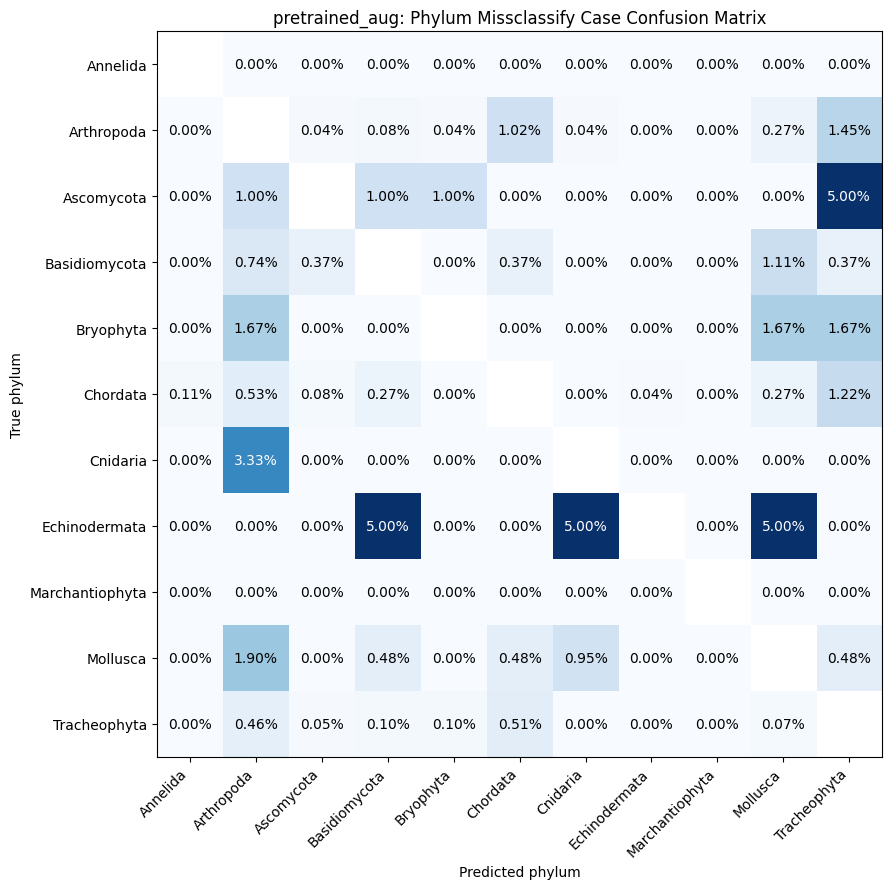

In [47]:
experiment_chosen = "pretrained_aug"

predictions = saved_test_predictions[experiment_chosen].copy()
species_to_phylum = {
    int(i): name.split("_")[2] for i, name in id2label.items()
}
predictions["true_phylum"] = predictions["true_species_id"].map(species_to_phylum)
predictions["prediction_phylum"] = predictions["prediction_species_id"].map(
    species_to_phylum
)

y_true = predictions["true_phylum"]
y_pred = predictions["prediction_phylum"]

phylum_metrics = {
    "accuracy": float(accuracy_score(y_true, y_pred)),
    "macro_precision": float(
        precision_score(y_true, y_pred, average="macro", zero_division=0)
    ),
    "macro_recall": float(
        recall_score(y_true, y_pred, average="macro", zero_division=0)
    ),
}

print(f"Phylum-level metrics ({experiment_chosen}):")
for key, value in phylum_metrics.items():
    print(f"  {key}: {value:.4f}")

phyla = sorted(set(species_to_phylum.values()))
phylum_counts = pd.crosstab(
    predictions["true_phylum"],
    predictions["prediction_phylum"],
).reindex(index=phyla, columns=phyla, fill_value=0)

phylum_percentages = (
    phylum_counts.div(phylum_counts.sum(axis=1), axis=0) * 100
)

heatmap_values = phylum_percentages.to_numpy().copy()
np.fill_diagonal(heatmap_values, np.nan)
maximum_error = np.nanmax(heatmap_values)
colour_map = plt.cm.Blues.copy()
colour_map.set_bad("white")

figure, axis = plt.subplots(figsize=(9, 9))
axis.imshow(
    heatmap_values,
    cmap=colour_map,
    vmin=0,
    vmax=maximum_error if maximum_error > 0 else 1,
)

axis.set_xticks(np.arange(len(phyla)))
axis.set_yticks(np.arange(len(phyla)))
axis.set_xticklabels(phyla, rotation=45, ha="right")
axis.set_yticklabels(phyla)
axis.set_xlabel("Predicted phylum")
axis.set_ylabel("True phylum")
axis.set_title(f"{experiment_chosen}: Phylum Missclassify Case Confusion Matrix")

for row in range(len(phyla)):
    for column in range(len(phyla)):
        if row == column:
            continue
        value = phylum_percentages.iat[row, column]
        axis.text(
            column,
            row,
            f"{value:.2f}%",
            ha="center",
            va="center",
            color=(
                "white"
                if maximum_error > 0 and value >= maximum_error / 2
                else "black"
            ),
        )

figure.tight_layout()
plt.show()

In [37]:
phylum_species_table = (
    pd.Series(species_to_phylum)
    .value_counts()
    .reindex(phyla)
    .rename("number_of_species")
    .rename_axis("phylum")
    .reset_index()
)

phylum_sample_counts = predictions['true_phylum'].value_counts().reset_index()
phylum_sample_counts.columns = ['phylum', 'number_of_samples']

phylum_species_table = pd.merge(phylum_species_table, phylum_sample_counts, on='phylum', how='left')
display(phylum_species_table)

,phylum,number_of_species,number_of_samples
0,Annelida,1,10
1,Arthropoda,255,2550
2,Ascomycota,10,100
3,Basidiomycota,27,270
4,Bryophyta,6,60
5,Chordata,262,2620
6,Cnidaria,3,30
7,Echinodermata,2,20
8,Marchantiophyta,1,10
9,Mollusca,21,210


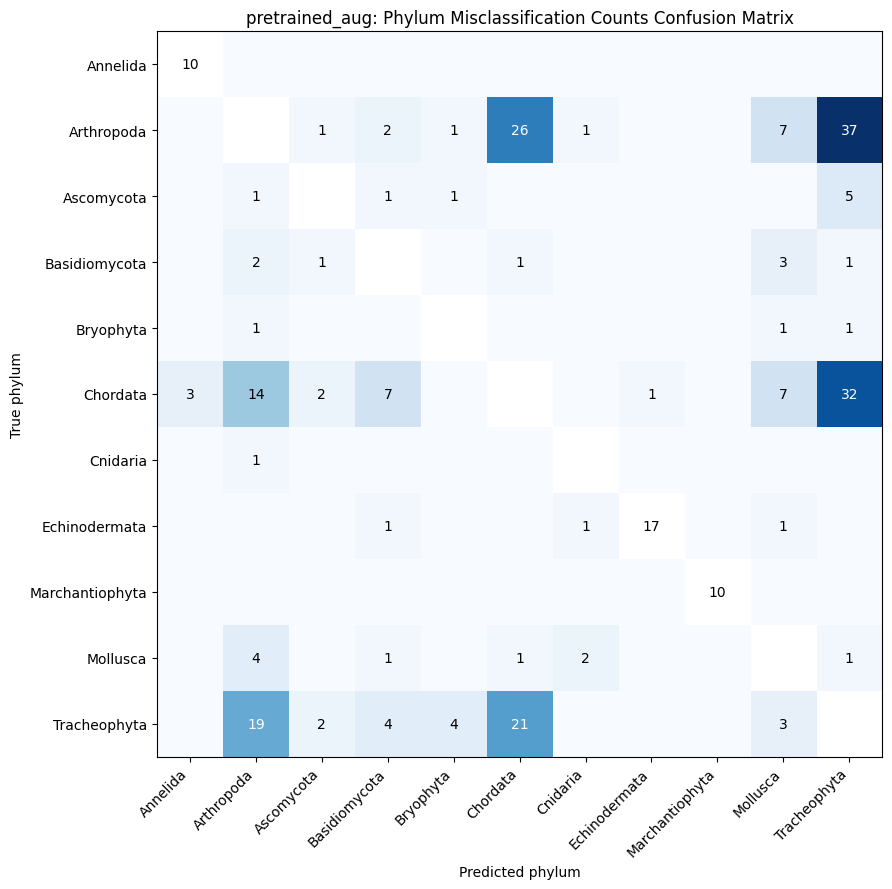

In [48]:
phylum_counts_raw = pd.crosstab(
    predictions["true_phylum"],
    predictions["prediction_phylum"],
).reindex(index=phyla, columns=phyla, fill_value=0)

heatmap_values_raw = phylum_counts_raw.to_numpy().copy().astype(float)

np.fill_diagonal(heatmap_values_raw, np.nan)
maximum_value_raw = np.nanmax(heatmap_values_raw)
colour_map_raw = plt.cm.Blues.copy()
colour_map_raw.set_bad("white")

figure_raw, axis_raw = plt.subplots(figsize=(9, 9))
axis_raw.imshow(
    heatmap_values_raw,
    cmap=colour_map_raw,
    vmin=0,
    vmax=maximum_value_raw if maximum_value_raw > 0 else 1,
)

axis_raw.set_xticks(np.arange(len(phyla)))
axis_raw.set_yticks(np.arange(len(phyla)))
axis_raw.set_xticklabels(phyla, rotation=45, ha="right")
axis_raw.set_yticklabels(phyla)
axis_raw.set_xlabel("Predicted phylum")
axis_raw.set_ylabel("True phylum")
axis_raw.set_title(f"{experiment_chosen}: Phylum Misclassification Counts Confusion Matrix")

for row in range(len(phyla)):
    for column in range(len(phyla)):
        value_raw = phylum_counts_raw.iat[row, column]
        if value_raw > 0:
            axis_raw.text(
                column,
                row,
                f"{int(value_raw)}",
                ha="center",
                va="center",
                color=(
                    "white"
                    if maximum_value_raw > 0 and value_raw >= maximum_value_raw / 2
                    else "black"
                ),
            )

figure_raw.tight_layout()
plt.show()

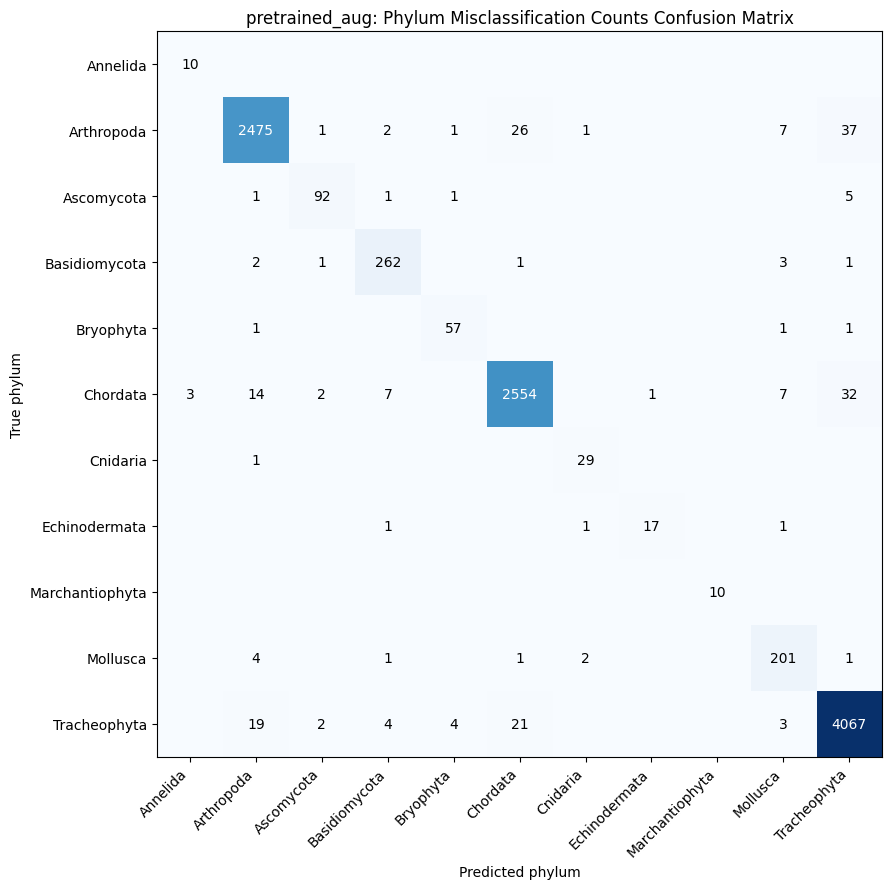

In [49]:
phylum_counts_raw = pd.crosstab(
    predictions["true_phylum"],
    predictions["prediction_phylum"],
).reindex(index=phyla, columns=phyla, fill_value=0)

heatmap_values_raw = phylum_counts_raw.to_numpy().copy().astype(float)

# np.fill_diagonal(heatmap_values_raw, np.nan)
maximum_value_raw = np.nanmax(heatmap_values_raw)
colour_map_raw = plt.cm.Blues.copy()
# colour_map_raw.set_bad("white")

figure_raw, axis_raw = plt.subplots(figsize=(9, 9))
axis_raw.imshow(
    heatmap_values_raw,
    cmap=colour_map_raw,
    vmin=0,
    vmax=maximum_value_raw if maximum_value_raw > 0 else 1,
)

axis_raw.set_xticks(np.arange(len(phyla)))
axis_raw.set_yticks(np.arange(len(phyla)))
axis_raw.set_xticklabels(phyla, rotation=45, ha="right")
axis_raw.set_yticklabels(phyla)
axis_raw.set_xlabel("Predicted phylum")
axis_raw.set_ylabel("True phylum")
axis_raw.set_title(f"{experiment_chosen}: Phylum Misclassification Counts Confusion Matrix")

for row in range(len(phyla)):
    for column in range(len(phyla)):
        value_raw = phylum_counts_raw.iat[row, column]
        if value_raw > 0:
            axis_raw.text(
                column,
                row,
                f"{int(value_raw)}",
                ha="center",
                va="center",
                color=(
                    "white"
                    if maximum_value_raw > 0 and value_raw >= maximum_value_raw / 2
                    else "black"
                ),
            )

figure_raw.tight_layout()
plt.show()